In [ ]:
# Enable autoreload to pick up code changes
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd

# Add parent directory to path to import from src/
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root: {project_root}")

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Import config loader and data preprocessing
from src.config_loader import load_config
from src.data_preprocessing import preprocess_soil_data

# Import gradient-based sampling utilities
from src.gradient_based_sampling import (
    gradient_based_sampling,
    visualize_gradient_sampling,
    compute_gradient_weights
)

# Import training function
from src.train_loop import finetune_pinn

# Import visualization
from src.visualization import plot_comprehensive_results, plot_training_losses

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Number of GPUs: {torch.cuda.device_count()}")

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✓ Modules loaded successfully")

In [ ]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Path to base checkpoint (from initial training)
BASE_CHECKPOINT = '../notebooks/checkpoints_train/checkpoint_final.pt'

# ============================================================================
# CONFIG FILE SELECTION - Choose your dataset for fine-tuning:
# ============================================================================
# Option 1: Calhoun CCZO fine-tuning (different time period than baseline)
config_file = '../configs/finetune_calhoun.yaml'

# Option 2: Use baseline config (same period - not recommended for fine-tuning)
# config_file = '../configs/baseline.yaml'

# Option 3: US-Uaf data (uncomment to use)
# config_file = '../configs/us_uaf_2019.yaml'

# Option 4: Your own dataset (create a new config file first)
# config_file = '../configs/your_dataset.yaml'

print("="*70)
print("FINE-TUNING CONFIGURATION")
print("="*70)
print(f"Base checkpoint: {BASE_CHECKPOINT}")
print(f"Config file: {config_file}")

# Load configuration
config = load_config(config_file)

# Fix data path if running from notebook (config paths are relative to project root)
if not os.path.isabs(config.data_path) and not os.path.exists(config.data_path):
    # Try prepending ../ for notebook context
    test_path = os.path.join('..', config.data_path)
    if os.path.exists(test_path):
        # Temporarily modify the config's internal data path
        config._config['data']['path'] = test_path
        print(f"Note: Adjusted data path for notebook context: {test_path}")

# Get network configurations from config (must match base training)
h_net_config = config.h_net_config
zb_net_config = config.zb_net_config

# Get initial water table depth from config
ZB_INITIAL = config.zb_initial

print(f"\nNetwork configurations:")
print(f"  h_net:  {h_net_config}")
print(f"  zb_net: {zb_net_config}")
print(f"\nData configuration:")
print(f"  Data path: {config.data_path}")
print(f"  Date range: {config.start_date} to {config.end_date}")
print(f"  Initial water table: {ZB_INITIAL} m")
print(f"\nFine-tuning settings:")
print(f"  Epochs: {config.n_epochs} (fewer than base training)")
print(f"  Learning rate: {config.learning_rate} (lower than base training)")
print(f"  Weight updates: Fixed (no adaptive updates)")
print("="*70)

In [ ]:
# ============================================================================
# LOAD SOIL MOISTURE DATA FOR FINE-TUNING USING CONFIG
# ============================================================================

print("="*70)
print("LOADING SOIL MOISTURE DATA FOR FINE-TUNING")
print("="*70)

# Preprocess data using config (handles column mapping automatically)
preprocessed_data = preprocess_soil_data(config, output_path='../data/preprocessed_finetune.pkl')

# Extract data
datetime_col = preprocessed_data['datetime_col']
times_seconds = preprocessed_data['times_seconds']

# Get available depths from the preprocessed data
available_depths = [key.replace('theta_', '') for key in preprocessed_data.keys() if key.startswith('theta_')]

# Extract theta values for each depth
theta_2cm = preprocessed_data.get('theta_2cm')
theta_15cm = preprocessed_data.get('theta_15cm')
theta_30cm = preprocessed_data.get('theta_30cm')
theta_40cm = preprocessed_data.get('theta_40cm')
theta_60cm = preprocessed_data.get('theta_60cm')
theta_80cm = preprocessed_data.get('theta_80cm')

# Build depths list and dict from available data
depths_names = []
theta_depths_dict = {}
for depth_name in ['2cm', '15cm', '30cm', '40cm', '60cm', '80cm']:
    key = f'theta_{depth_name}'
    if key in preprocessed_data:
        depths_names.append(depth_name)
        theta_depths_dict[depth_name] = preprocessed_data[key]

print("\n" + "="*70)
print("DATA LOADED SUCCESSFULLY")
print("="*70)
print(f"Time range: {datetime_col.iloc[0]} to {datetime_col.iloc[-1]}")
print(f"Duration: {times_seconds[-1]/86400:.2f} days")
print(f"Total points: {len(times_seconds)}")
print(f"Loaded depths: {depths_names}")
print("="*70)

In [ ]:
# ============================================================================
# VISUALIZE NEW SURFACE MOISTURE DATA
# ============================================================================

# Use surface layer (first available depth)
if theta_2cm is not None:
    theta_surface = theta_2cm
    surface_depth_name = '2cm'
elif len(depths_names) > 0:
    surface_depth_name = depths_names[0]
    theta_surface = theta_depths_dict[surface_depth_name]
else:
    raise ValueError("No surface moisture data available!")

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(datetime_col, theta_surface, 'b-', linewidth=1.5, alpha=0.7, 
        label=f'Surface moisture ({surface_depth_name})')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('θ (m³/m³)', fontsize=12)
ax.set_title(f'New Soil Moisture Data for Fine-Tuning: {config.start_date} to {config.end_date}', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Statistics
valid_mask = ~pd.isna(theta_surface)
theta_valid = theta_surface[valid_mask]
print(f"\nSurface Moisture Statistics ({surface_depth_name}):")
print(f"  Valid points: {valid_mask.sum()} / {len(theta_surface)}")
print(f"  Range: {theta_valid.min():.4f} - {theta_valid.max():.4f} m³/m³")
print(f"  Mean: {theta_valid.mean():.4f} m³/m³")
print(f"  Std: {theta_valid.std():.4f} m³/m³")

In [ ]:
# ============================================================================
# PREPARE BOUNDARY CONDITION DATA (DIRICHLET BC)
# ============================================================================

# Use surface layer for BC
if theta_2cm is not None:
    theta_surface_bc = theta_2cm
elif len(depths_names) > 0:
    theta_surface_bc = theta_depths_dict[depths_names[0]]
else:
    raise ValueError("No surface moisture data available!")

# Remove NaN values from surface moisture
valid_mask = ~pd.isna(theta_surface_bc)
theta0_times = times_seconds[valid_mask]
theta0_values = theta_surface_bc[valid_mask]

# Convert to numpy arrays
theta0_times = np.array(theta0_times, dtype=np.float64)
theta0_values = np.array(theta0_values, dtype=np.float64)

# Create theta0_data tuple for training
new_theta0_data = (theta0_times, theta0_values)

print("="*70)
print("BOUNDARY CONDITION DATA PREPARED")
print("="*70)
print(f"BC Type: Dirichlet (prescribed moisture)")
print(f"  Surface BC: θ(z=0, t) = θ₀(t)")
print(f"  Data points: {len(new_theta0_data[0])}")
print(f"  Time range: {new_theta0_data[0][0]:.1f} - {new_theta0_data[0][-1]:.1f} s")
print(f"  Duration: {new_theta0_data[0][-1]/86400:.2f} days")
print(f"  Moisture range: {new_theta0_data[1].min():.4f} - {new_theta0_data[1].max():.4f} m³/m³")
print("="*70)


TESTING GRADIENT-BASED SAMPLING

Gradient Statistics:
  Max |dθ/dt|:  1.807e-05 m³/m³/s
  Mean |dθ/dt|: 5.161e-07 m³/m³/s
  Min |dθ/dt|:  0.000e+00 m³/m³/s

Generated 400 samples:
  Interpolated:  133 (33.2%)
  Neighbors:     66 (16.5%)
  Baseline:      201 (50.2%)


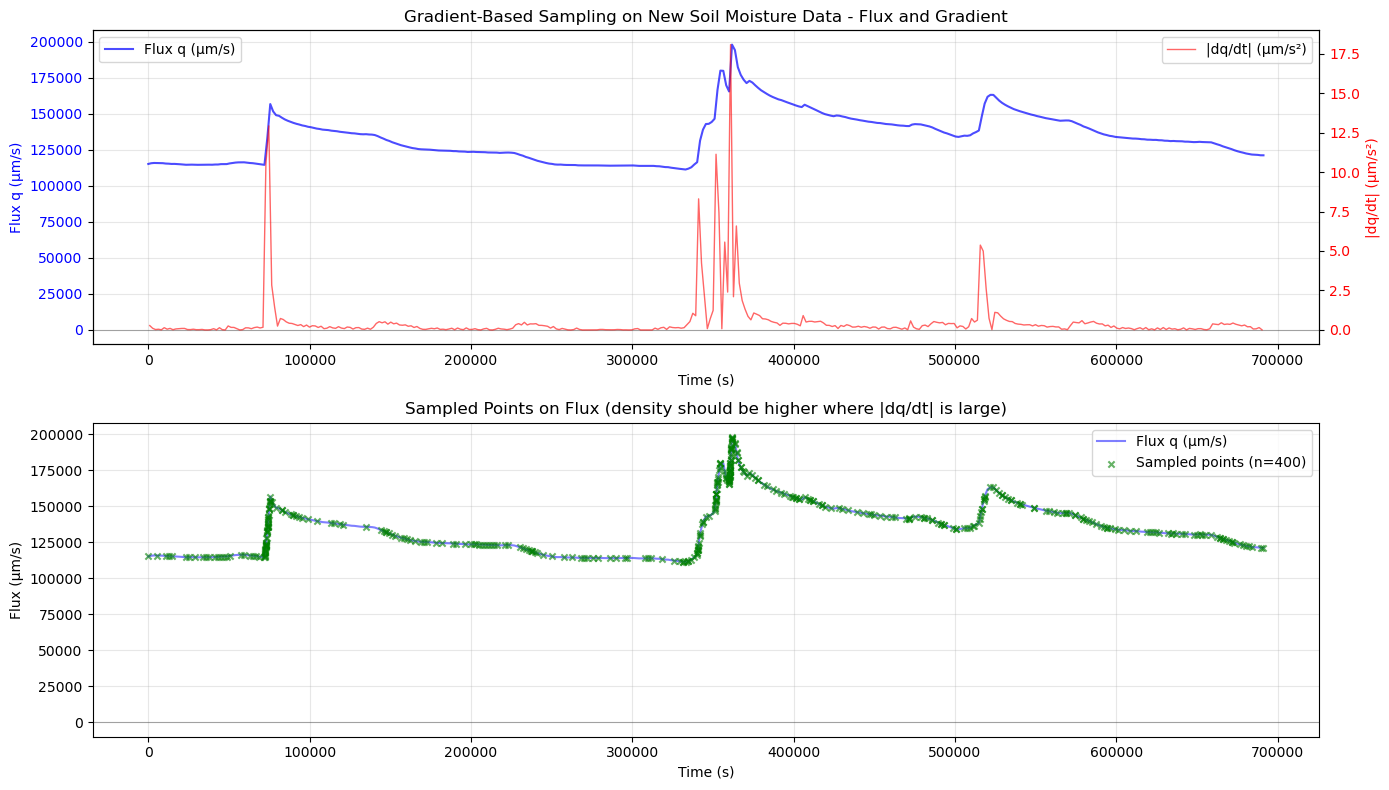

In [17]:
# ============================================================================
# TEST GRADIENT-BASED SAMPLING ON NEW DATA
# ============================================================================

print("\n" + "="*70)
print("TESTING GRADIENT-BASED SAMPLING")
print("="*70)

# Convert to tensors
theta0_times_t = torch.tensor(theta0_times, dtype=torch.float32).to(device)
theta0_values_t = torch.tensor(theta0_values, dtype=torch.float32).to(device)

# Compute gradients
gradient_weights, gradients = compute_gradient_weights(theta0_times_t, theta0_values_t, device)

print(f"\nGradient Statistics:")
print(f"  Max |dθ/dt|:  {gradients.abs().max().item():.3e} m³/m³/s")
print(f"  Mean |dθ/dt|: {gradients.abs().mean().item():.3e} m³/m³/s")
print(f"  Min |dθ/dt|:  {gradients.abs().min().item():.3e} m³/m³/s")

# Test sampling
t_bc_test, sample_info = gradient_based_sampling(
    theta0_times_t,
    theta0_values_t,
    batch_size_bc=400,
    device=device,
    use_interpolation=True,
    interp_ratio=0.10,
    neighbor_ratio=0.05,
    baseline_ratio=0.15,
    neighbor_expansion=2,
    gradient_threshold=0.7,
    power=2.0
)

print(f"\nGenerated {len(t_bc_test)} samples:")
print(f"  Interpolated:  {sample_info['n_interp_samples']} ({sample_info['actual_ratios']['interp']*100:.1f}%)")
print(f"  Neighbors:     {sample_info['n_neighbor_samples']} ({sample_info['actual_ratios']['neighbor']*100:.1f}%)")
print(f"  Baseline:      {sample_info['n_baseline_samples']} ({sample_info['actual_ratios']['baseline']*100:.1f}%)")

# Visualize
visualize_gradient_sampling(
    theta0_times_t,
    theta0_values_t,
    t_bc_test,
    sample_info,
    title='Gradient-Based Sampling on New Soil Moisture Data'
)
plt.show()

In [ ]:
# ============================================================================
# PREPARE INITIAL CONDITION FROM MEASURED PROFILE
# ============================================================================

# Use the IC profile that was already prepared during preprocessing
ic_profile = preprocessed_data['ic_profile']

print("="*70)
print("INITIAL CONDITION FROM MEASURED THETA PROFILE")
print("="*70)
print(f"IC Profile has {len(ic_profile['depths'])} measurement points:")
for depth_m, theta_val in zip(ic_profile['depths'], ic_profile['theta']):
    depth_cm = depth_m * 100
    print(f"  {depth_cm:6.1f}cm: θ = {theta_val:.4f} m³/m³")
print("="*70)

In [ ]:
# ============================================================================
# FINE-TUNE PINN WITH NEW MOISTURE DATA
# ============================================================================

print("\n" + "="*70)
print("STARTING FINE-TUNING")
print("="*70)

# Get sampling parameters from config
batch_size_bc = config.batch_size_bc
interp_ratio = config.interp_ratio
neighbor_ratio = config.neighbor_ratio
baseline_ratio = config.baseline_ratio
neighbor_expansion = config.gradient_neighbor_expansion
gradient_threshold = config.gradient_threshold
power = config.gradient_power

print(f"Gradient-based BC sampling config:")
print(f"  Batch size: {batch_size_bc}")
print(f"  Interp ratio: {interp_ratio}")
print(f"  Neighbor ratio: {neighbor_ratio}")
print(f"  Baseline ratio: {baseline_ratio}")
print()

model, losses, comps, sample_losses, sample_comps, sample_epochs = finetune_pinn(
    checkpoint_path=BASE_CHECKPOINT,
    new_theta0_data=new_theta0_data,  # NEW moisture BC data
    zb_initial=ZB_INITIAL,
    h_net_config=h_net_config,
    zb_net_config=zb_net_config,

    # Fine-tuning hyperparameters (LOWER lr, FEWER epochs)
    n_epochs=10000,
    learning_rate=1e-4,  # Lower than base training

    # Sampling parameters
    cache_size=config.cache_size,
    batch_size=config.batch_size,
    resample_freq=config.resample_freq,
    boundary_ratio=config.boundary_ratio,

    # Gradient-based boundary sampling
    batch_size_bc=batch_size_bc,
    interp_ratio=interp_ratio,
    neighbor_ratio=neighbor_ratio,
    baseline_ratio=baseline_ratio,
    gradient_neighbor_expansion=neighbor_expansion,
    gradient_threshold=gradient_threshold,
    gradient_power=power,

    # Weight management (FIXED weights for fine-tuning)
    weight_update_freq=1e10,  # No adaptive weight updates
    weight_lr=config.weight_lr,
    use_initial_scales=config.use_initial_scales,

    # Initial condition
    ic_profile=ic_profile,
    ic_type=config.ic_type,

    # Device and GPU settings
    device=device,
    use_multi_gpu=config.use_multi_gpu,
    use_amp=config.use_amp,
    grad_accumulation_steps=config.grad_accumulation_steps,

    # Checkpointing (isolated from base training)
    checkpoint_dir='../checkpoints_finetune',
    checkpoint_freq=2000,
    keep_last_n_checkpoints=3,
)

print("\n" + "="*70)
print("FINE-TUNING COMPLETE!")
print("="*70)

In [ ]:
# ============================================================================
# VISUALIZE FINE-TUNED MODEL
# ============================================================================

# Load soil parameters from checkpoint (must match base training)
checkpoint = torch.load(BASE_CHECKPOINT, map_location=device)
soil_params = checkpoint['normalization_params']['soil_params']

print("="*70)
print("SOIL PARAMETERS (from base checkpoint):")
print("="*70)
for key, val in soil_params.items():
    print(f"  {key}: {val}")
print("="*70)

# Prepare observation data for validation (dynamic for variable depths)
obs_depths = []
obs_theta = []
for depth_name in depths_names:
    # Convert depth name to meters (negative for plotting)
    if depth_name.endswith('cm'):
        depth_m = -float(depth_name[:-2]) / 100.0
    elif depth_name.endswith('m'):
        depth_m = -float(depth_name[:-1])
    else:
        continue
    
    obs_depths.append(depth_m)
    obs_theta.append(theta_depths_dict[depth_name])

obs_data_viz = {
    'times': times_seconds,
    'depths': obs_depths,  # Negative (below surface)
    'theta': obs_theta
}

# Plot comprehensive results
model.eval()
plot_comprehensive_results(
    model, 
    new_theta0_data, 
    soil_params, 
    device=device, 
    obs_data=obs_data_viz
)

# ============================================================================
# PLOT TRAINING LOSSES
# ============================================================================

plot_training_losses(losses, comps, sample_losses, sample_comps, sample_epochs)

In [ ]:
# ============================================================================
# SAVE FINE-TUNED MODEL (Optional)
# ============================================================================

# The model is automatically saved to checkpoints_finetune/ during training
# You can also manually save the final model here if needed

import datetime

output_path = f'../checkpoints_finetune/finetuned_{config.start_date}_to_{config.end_date}.pt'

# Save checkpoint with metadata
checkpoint_save = {
    'model_state_dict': model.state_dict() if not hasattr(model, 'module') else model.module.state_dict(),
    'epoch': 10000,
    'base_checkpoint': BASE_CHECKPOINT,
    'finetune_period': f'{config.start_date} to {config.end_date}',
    'config_file': config_file,
    'timestamp': datetime.datetime.now().isoformat(),
}

torch.save(checkpoint_save, output_path)
print(f"✓ Fine-tuned model saved to: {output_path}")